In [1]:
# python
import sys
import importlib
# columnar analysis
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, utilities, scaleout, selection, llpnanoaodschema
#from sidm.tools import llpnanoaodschema_0726 as llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
importlib.reload(scaleout)
importlib.reload(selection)
importlib.reload(llpnanoaodschema)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
from hist import Hist

In [2]:
samples = [    
    '2Mu2E_100GeV_0p25GeV_0p2mm',
    '2Mu2E_100GeV_0p25GeV_10p0mm',
    '2Mu2E_100GeV_0p25GeV_20p0mm',
    
    '2Mu2E_100GeV_1p2GeV_0p96mm',
    '2Mu2E_100GeV_1p2GeV_48p0mm',
    '2Mu2E_100GeV_1p2GeV_96p0mm',
    
    '2Mu2E_100GeV_5p0GeV_4p0mm',
    '2Mu2E_100GeV_5p0GeV_200mm',
    '2Mu2E_100GeV_5p0GeV_400mm',

    '2Mu2E_500GeV_0p25GeV_0p04mm',
    '2Mu2E_500GeV_0p25GeV_2p0mm',
    '2Mu2E_500GeV_0p25GeV_4p0mm',

    '2Mu2E_500GeV_1p2GeV_0p19mm',
    '2Mu2E_500GeV_1p2GeV_9p6mm',
    '2Mu2E_500GeV_1p2GeV_19p0mm',

    '2Mu2E_500GeV_5p0GeV_0p8mm',
    '2Mu2E_500GeV_5p0GeV_40p0mm',
    '2Mu2E_500GeV_5p0GeV_80p0mm',
    
    '2Mu2E_1000GeV_0p25GeV_0p02mm',
    '2Mu2E_1000GeV_0p25GeV_1p0mm',
    '2Mu2E_1000GeV_0p25GeV_2p0mm',

    '2Mu2E_1000GeV_1p2GeV_0p096mm',
    '2Mu2E_1000GeV_1p2GeV_4p8mm',
    '2Mu2E_1000GeV_1p2GeV_9p6mm',

    '2Mu2E_1000GeV_5p0GeV_0p4mm',
    '2Mu2E_1000GeV_5p0GeV_20p0mm',
    '2Mu2E_1000GeV_5p0GeV_40p0mm',
]

fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=1, location_cfg="signal_2mu2e_v10.yaml")

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.DaskExecutor(client=client),
    #schema=NanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

channels = [
    "baseNoTriggerNoLjNoLjsource",
    "notrigger_2dsamu",
#    'notrigger_2dsamu1muLJ',
#    'notrigger_2dsamu1muLJ_0charge',
    '2dsa1muLj',
    '2dsa1muLj0charge',
    '2dsa1muLjCC',
    '2dsa1muLj0chargeCC',
    '2dsa1muLjCCnocharge',
    '2dsa1muLj0chargeCCnocharge',
]

p = sidm_processor.SidmProcessor(
    channels,
    ["genA_toMu_base"],
    verbose=True,
)


out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]

Output()

Processing 2Mu2E_100GeV_0p25GeV_0p2mm


Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

...

Warning: a histogram with the name genAs_toMu_lxy_MuMudR_XLowRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_lxy_MuMudR_XXLowRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_pt_MuMudR_highRange could not be filled and will be skipped

Warning: a histogram with the name genAs_toMu_pt_highRange_MuMudR_lowRange could not be filled and will be skipped

Signal not in xs cfg, assuming 1fb


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


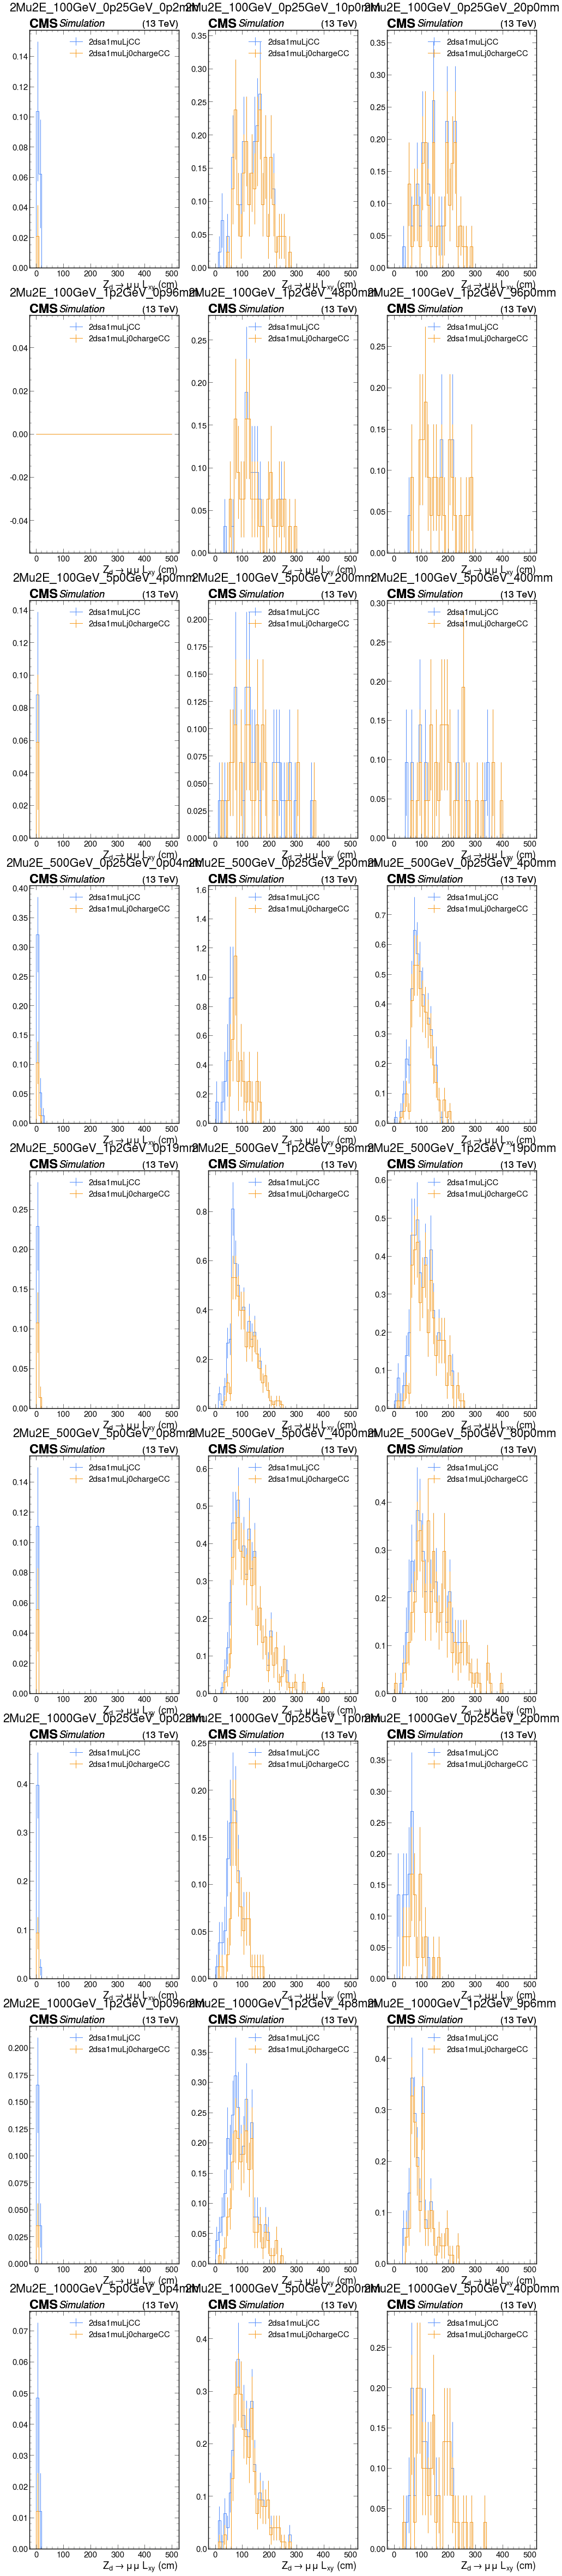

In [3]:
plt.subplots(9, 3, figsize=(24, 120))
for i in range(27):
    plt.subplot(9, 3, i+1)
    channel1 = 0
    channel2 = 1
    channel3 = 4
    channel4 = 5
    channel5 = 6
    channel6 = 7
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


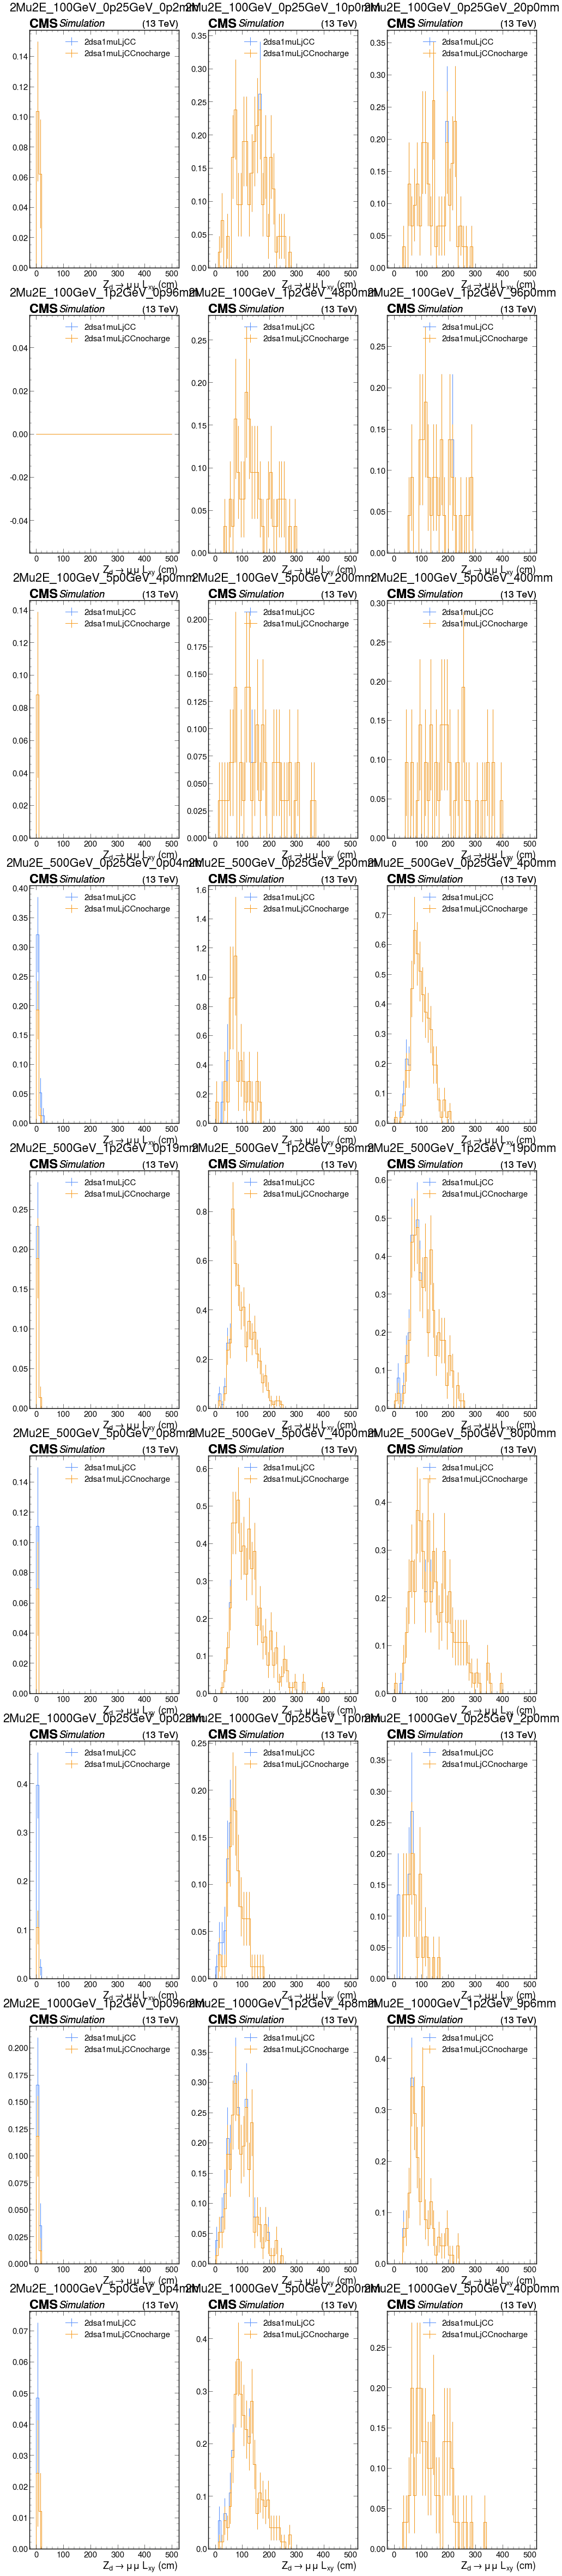

In [4]:
plt.subplots(9, 3, figsize=(24, 120))
for i in range(27):
    plt.subplot(9, 3, i+1)
    channel1 = 0
    channel2 = 1
    channel3 = 4
    channel4 = 5
    channel5 = 6
    channel6 = 7
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

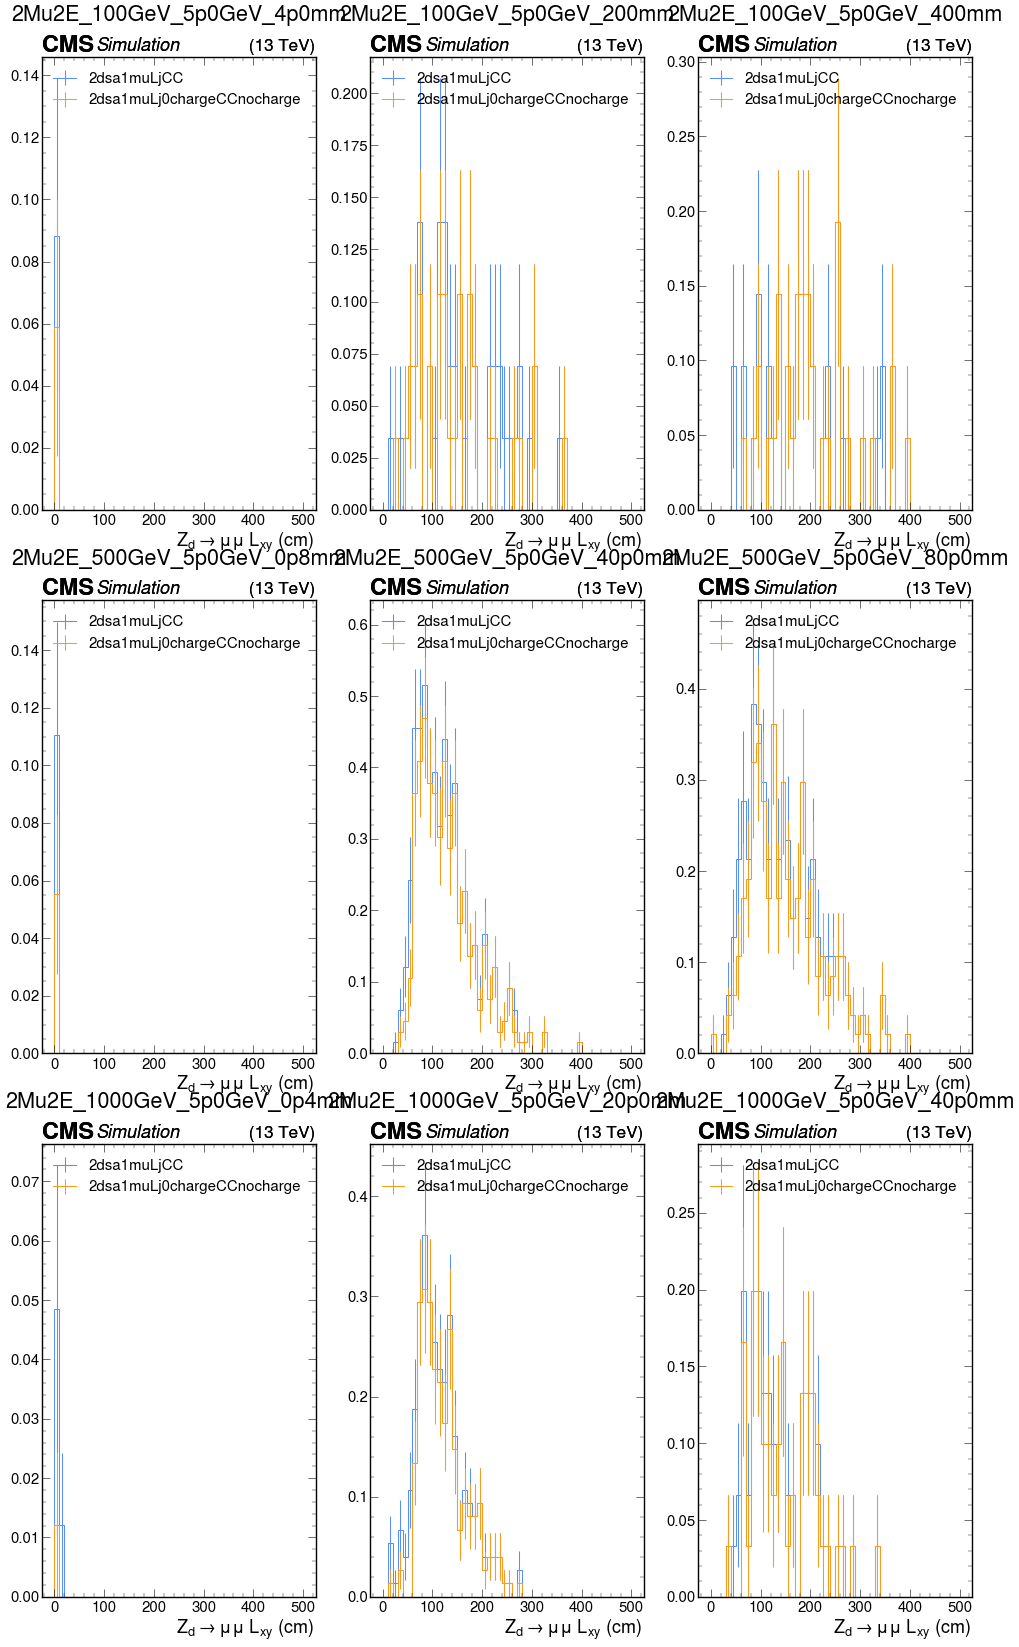

In [6]:
plt.subplots(3, 3, figsize=(24, 40))
for i in range(9):
    plt.subplot(3, 3, i+1)
    channel1 = 0
    channel2 = 1
    channel3 = 4
    channel4 = 5
    channel5 = 6
    channel6 = 7
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_children_absPdgId"][channels[channel1], ::2j],label=channels[channel1])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_children_absPdgId"][channels[channel2], ::2j],label=channels[channel2])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

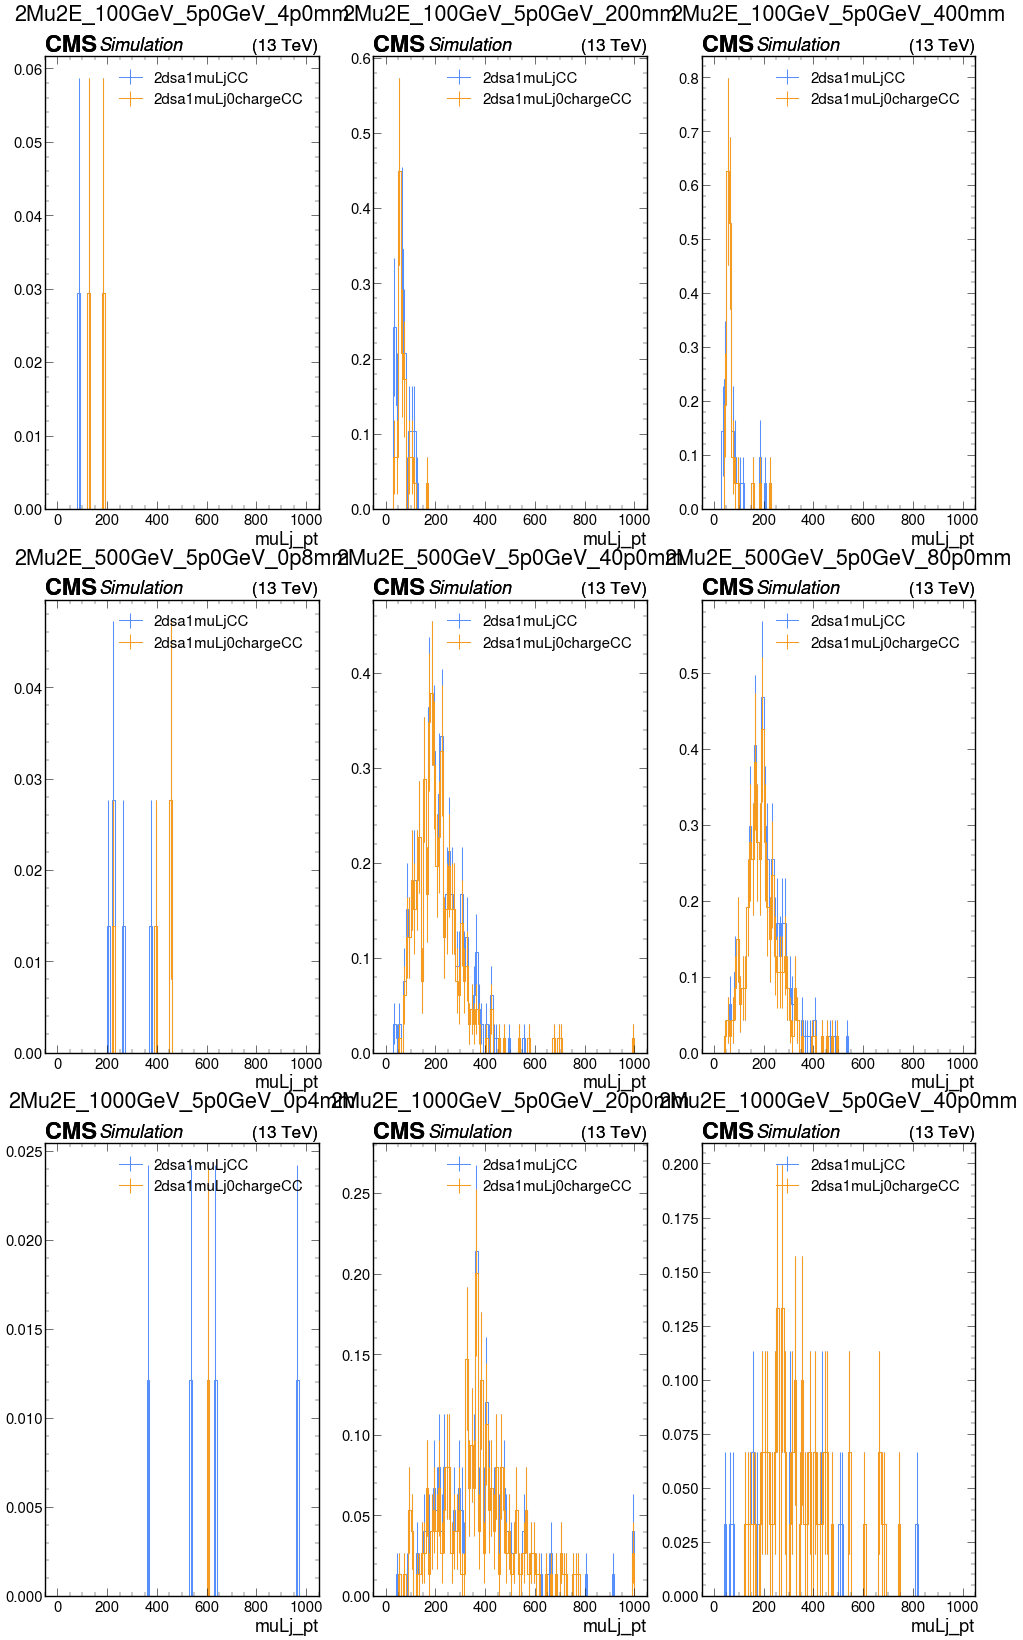

In [7]:
plt.subplots(3, 3, figsize=(24, 40))
for i in range(9):
    plt.subplot(3, 3, i+1)
    channel1 = 0
    channel2 = 1
    channel3 = 4
    channel4 = 5
    channel5 = 6
    channel6 = 7
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_children_absPdgId"][channels[channel1], ::2j],label=channels[channel1])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_children_absPdgId"][channels[channel2], ::2j],label=channels[channel2])
    utilities.plot(out[samples[i]]["hists"]["muLj_matched_genAs_toMu_pt"][channels[channel3], ::2j],label=channels[channel3])
    utilities.plot(out[samples[i]]["hists"]["muLj_matched_genAs_toMu_pt"][channels[channel4], ::2j],label=channels[channel4])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


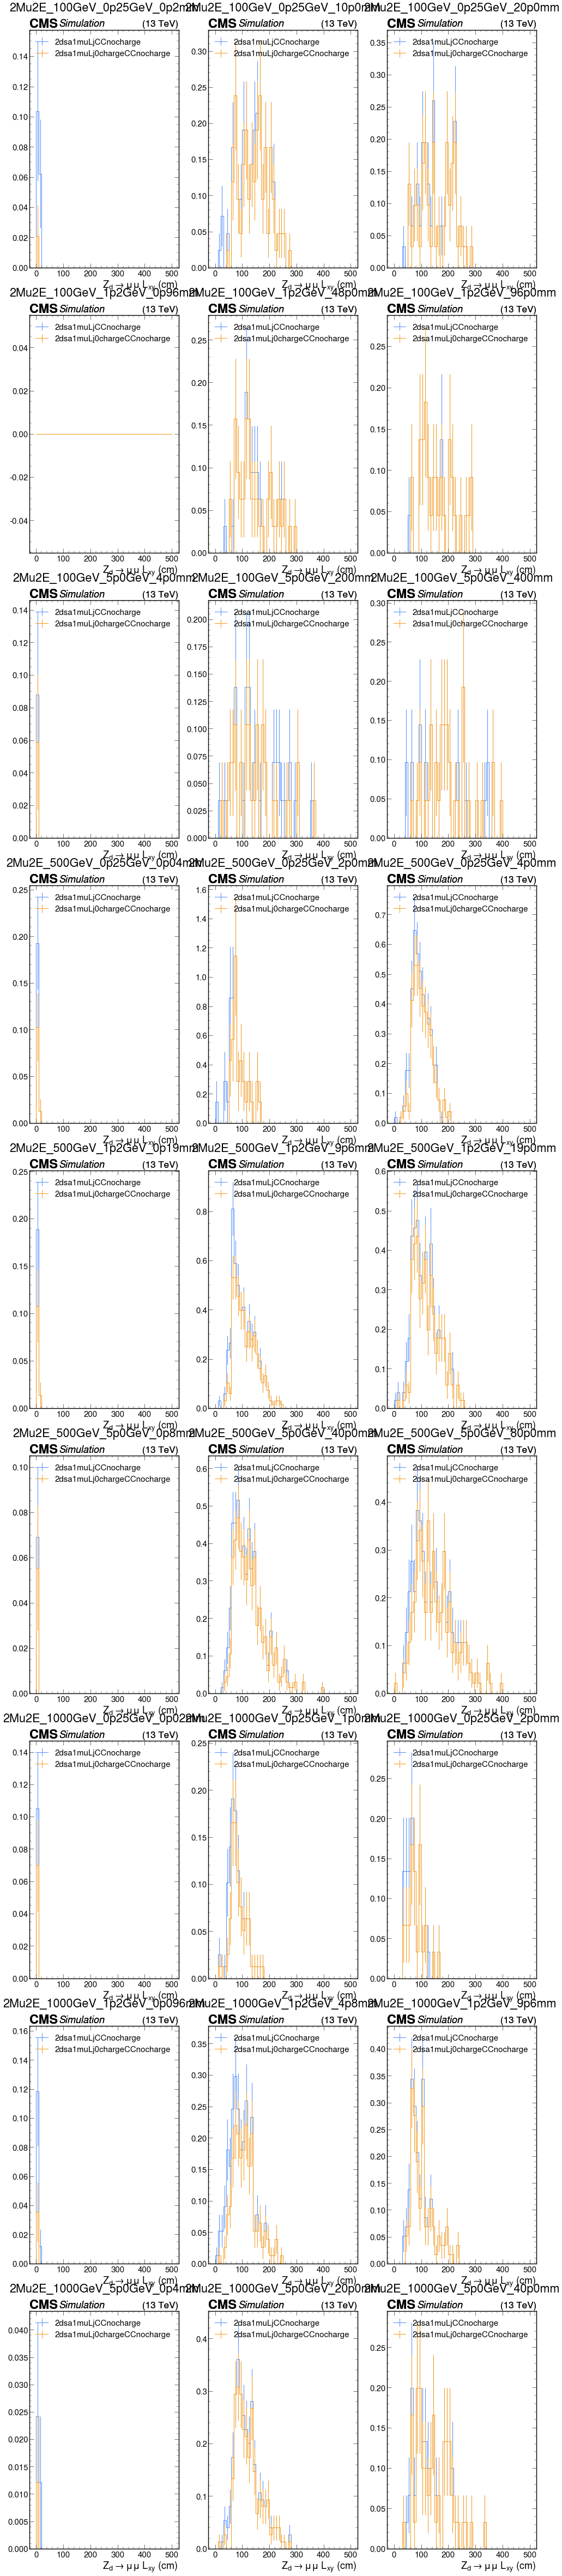

In [5]:
plt.subplots(9, 3, figsize=(24, 120))
for i in range(27):
    plt.subplot(9, 3, i+1)
    channel1 = 0
    channel2 = 1
    channel3 = 4
    channel4 = 5
    channel5 = 6
    channel6 = 7
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel1], ::2j],label=channels[channel1])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel2], ::2j],label=channels[channel2])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel3], ::2j],label=channels[channel3])
    #utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel4], ::2j],label=channels[channel4])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel5], ::2j],label=channels[channel5])
    utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channels[channel6], ::2j],label=channels[channel6])
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[i],y=1.07)